In [1]:
import os, math, random, shutil
import numpy as np
import tensorflow as tf
import keras
from keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

DATA_DIR = "/home/lurpd/DevelopmentWSL2/Datasets/BWSET/train"
IMG_SIZE = 256
BATCH = 64
SEED = 42 


I0000 00:00:1765351655.015283   43019 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1765351655.050931   43019 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1765351655.777253   43019 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF: 2.21.0-dev20251017
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1765351656.648390   43019 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
#undersample

# --- Paths ---
original_dir = "/home/lurpd/DevelopmentWSL2/Datasets/BWSET/train"
balanced_dir = "/home/lurpd/DevelopmentWSL2/Datasets/BWSET/balanced"

# --- Clean previous balanced directory (if exists) ---
if os.path.exists(balanced_dir):
    shutil.rmtree(balanced_dir)
os.makedirs(balanced_dir, exist_ok=True)

# --- Count images in each class ---
class_counts = {}
for cls in os.listdir(original_dir):
    cls_path = os.path.join(original_dir, cls)
    if os.path.isdir(cls_path):
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('.')]
        class_counts[cls] = len(images)

print("Class counts:", class_counts)

# --- Find the smallest class size ---
target = min(class_counts.values())
print(f"\nUndersampling all classes to {target} images each\n")

# --- Undersample each class ---
for cls, count in class_counts.items():
    src_folder = os.path.join(original_dir, cls)
    dst_folder = os.path.join(balanced_dir, cls)
    os.makedirs(dst_folder, exist_ok=True)

    # Get random subset of images equal to smallest class size
    files = [f for f in os.listdir(src_folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('.')]
    sampled_files = random.sample(files, target)

    # Create symlinks (lightweight, doesn’t duplicate files)
    for f in sampled_files:
        src = os.path.join(src_folder, f)
        dst = os.path.join(dst_folder, f)
        os.symlink(src, dst)

# --- Verify counts ---
for cls in os.listdir(balanced_dir):
    c = len(os.listdir(os.path.join(balanced_dir, cls)))
    print(f"{cls}: {c} images")


Class counts: {'c2': 1525, 'c1': 2512, 'c0': 6180}

Undersampling all classes to 1525 images each

c2: 1525 images
c1: 1525 images
c0: 1525 images


In [3]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode='nearest'
)
val_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_gen.flow_from_directory(
    balanced_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)
val_generator = val_gen.flow_from_directory(
    balanced_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("Classes:", train_generator.class_indices)


Found 3660 images belonging to 3 classes.
Found 915 images belonging to 3 classes.
Classes: {'c0': 0, 'c1': 1, 'c2': 2}


In [4]:
#debug count data
import collections

class_counts = collections.Counter(train_generator.classes)
for cls, count in class_counts.items():
    print(f"{cls} ({list(train_generator.class_indices.keys())[cls]}): {count}")

0 (c0): 1220
1 (c1): 1220
2 (c2): 1220


(64, 256, 256, 1)
(64, 3)
(64, 256, 256, 1) 0.0 1.0


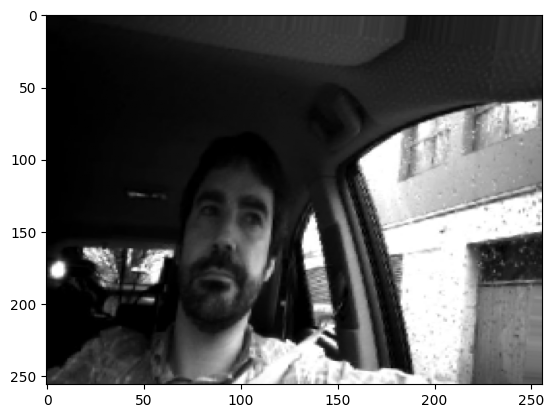

In [5]:
for data_batch,label_batch in train_generator:
    print(data_batch.shape) 
    print(label_batch.shape) 
    break

batch_x, batch_y = next(train_generator)
print(batch_x.shape, batch_x.min(), batch_x.max())
plt.imshow(np.squeeze(batch_x[0]), cmap='gray', aspect='auto')
plt.show()

In [6]:
#cpu handle random dropout cuz issue with CUDA
import tensorflow as tf
from keras.layers import Dropout

class CPUDropout(Dropout):
    def call(self, inputs, training=None):
        with tf.device('/CPU:0'):
            return super().call(inputs, training=training)


In [7]:
#CBAMN layers

@keras.saving.register_keras_serializable(package="ddd")
class ChannelAttention(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        c = int(input_shape[-1])
        hidden = max(c // self.ratio, 8)
        self.fc1 = layers.Dense(hidden, activation='relu', kernel_initializer='he_normal')
        self.fc2 = layers.Dense(c, activation='sigmoid', kernel_initializer='he_normal')
        self.fc1m = layers.Dense(hidden, activation='relu', kernel_initializer='he_normal')
        self.fc2m = layers.Dense(c, activation='sigmoid', kernel_initializer='he_normal')

    def call(self, x):
        avg = tf.reduce_sum(x, axis=[1,2]) / (tf.cast(tf.shape(x)[1]*tf.shape(x)[2], x.dtype))
        mx  = tf.reduce_max(x, axis=[1,2])
        ca = self.fc2(self.fc1(avg))
        cm = self.fc2m(self.fc1m(mx))
        w = tf.nn.sigmoid(ca + cm)
        w = tf.reshape(w, (-1,1,1,tf.shape(w)[-1]))
        return x * w

    def get_config(self):
        return {"ratio": self.ratio, **super().get_config()}

@keras.saving.register_keras_serializable(package="ddd")
class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')

    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x, axis=-1, keepdims=True)
        s = tf.concat([avg, mx], axis=-1)     # HxWx2
        s = self.conv(s)                      # HxWx1
        return x * s


In [8]:
WD = 1e-5 

def conv_bn_act(x, filters, k=3, s=1, act='swish', wd=WD):
    x = layers.Conv2D(filters, k, strides=s, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(wd))(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation(act)(x)

def se_block(x, reduction=8):
    c = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(max(c // reduction, 8), activation='relu', kernel_initializer='he_normal')(s)
    s = layers.Dense(c, activation='sigmoid', kernel_initializer='he_normal')(s)
    s = layers.Reshape((1,1,c))(s)
    return layers.Multiply()([x, s])

def residual_block(x, filters, stride=1, use_se=True, drop=0.0):
    shortcut = x
    y = conv_bn_act(x, filters, k=3, s=stride)
    y = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(WD))(y)
    y = layers.BatchNormalization()(y)
    if use_se:
        y = se_block(y)
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False,
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=regularizers.l2(WD))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    y = layers.Add()([shortcut, y])
    y = layers.Activation('swish')(y)
    if drop > 0.0:
        y = layers.SpatialDropout2D(drop)(y)
    return y

@keras.saving.register_keras_serializable(package="ddd")
class CBAM(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ca = ChannelAttention(ratio=ratio)
        self.sa = SpatialAttention()

    def call(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 1), n_classes=3):
    inputs = layers.Input(shape=input_shape)
    x = conv_bn_act(inputs, 32, k=5, s=2)  # 1/2
    x = layers.MaxPooling2D(2)(x)          # 1/4

    x = residual_block(x, 32, 1, drop=0.05)
    x = residual_block(x, 32, 1, drop=0.05)

    x = residual_block(x, 64, 2, drop=0.05)   # 1/8
    x = residual_block(x, 64, 1, drop=0.05)

    x = residual_block(x, 128, 2, drop=0.10)  # 1/16
    x = CBAM()(x)
    x = residual_block(x, 128, 1, drop=0.10)

    x = residual_block(x, 192, 2, drop=0.15)  # 1/32
    x = CBAM()(x)
    x = residual_block(x, 192, 1, drop=0.15)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='swish',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(WD))(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model()
model.summary()


W0000 00:00:1765351657.686145   43019 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1765351655.312691   43019 gpu_device.cc:2040] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        800 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      9,216 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      9,216 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 64, 64,    │          0 │ activation_2[0][

 Total params: 2,050,793 (7.82 MB)

 Trainable params: 2,046,633 (7.81 MB)

 Non-trainable params: 4,160 (16.25 KB)

In [9]:
def categorical_focal_loss(alpha, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=-1)
    return loss

# Heavier weight for the hard class (your c1)
alpha = [0.9, 1.6, 1.0]

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)


In [ ]:
#autocalculate class weight
labels = np.unique(train_generator.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=labels,
    y=train_generator.classes
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=75,
    callbacks=callbacks, 
)


# manual weights just in case
# class_weights = {
#     0: 0.55,  #Safe driving
#     1: 1.36,  #distracted
#     2: 2.55,  #tired
# }

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/75


I0000 00:00:1765351664.071869   43157 service.cc:158] XLA service 0x7364b8086930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765351664.071910   43157 service.cc:166]   StreamExecutor device (0): NVIDIA GeForce RTX 5070, Compute Capability 12.0a
I0000 00:00:1765351664.262414   43157 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1765351665.576992   43157 cuda_dnn.cc:463] Loaded cuDNN version 91400
I0000 00:00:1765351667.642135   43254 subprocess_compilation.cc:347] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_92', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1765351667.752051   43253 subprocess_compilation.cc:347] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_170', 8 bytes spill stores, 12 bytes spill loads

I0000 00:00:1765351667.796932   43265 subprocess_compil

 1/58 ━━━━━━━━━━━━━━━━━━━━ 24:30 26s/step - accuracy: 0.2188 - loss: 1.1843

I0000 00:00:1765351682.202007   43157 subprocess_compilation.cc:347] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion_3', 144 bytes spill stores, 148 bytes spill loads

I0000 00:00:1765351682.276888   43157 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


58/58 ━━━━━━━━━━━━━━━━━━━━ 54s 488ms/step - accuracy: 0.4352 - loss: 1.1024 - val_accuracy: 0.3333 - val_loss: 1.1657 - learning_rate: 1.0000e-04
Epoch 2/75
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.5246 - loss: 1.0012 - val_accuracy: 0.3333 - val_loss: 1.3212 - learning_rate: 1.0000e-04
Epoch 3/75
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.5423 - loss: 0.9653 - val_accuracy: 0.3333 - val_loss: 1.5510 - learning_rate: 1.0000e-04
Epoch 4/75
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.5754 - loss: 0.9342 - val_accuracy: 0.3333 - val_loss: 1.8277 - learning_rate: 1.0000e-04
Epoch 5/75
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.5855 - loss: 0.9113 - val_accuracy: 0.3333 - val_loss: 1.8868 - learning_rate: 1.0000e-04
Epoch 6/75
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.5981 - loss: 0.8971 - val_accuracy: 0.3333 - val_loss: 1.8751 - learning_rate: 5.0000e-05
Epoch 7/75
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.6213 - l

In [ ]:
#fine tune
from tensorflow.keras.optimizers import Adam

alpha = [0.4, 1.8, 1.0]  # c0, c1, c2
gamma = 1.5

model.compile(optimizer=tf.keras.optimizers.Adam(5e-6),
    loss=categorical_focal_loss(alpha=alpha, gamma=gamma),
    metrics=['accuracy'])


history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks, 
)


Epoch 1/20
 1/58 ━━━━━━━━━━━━━━━━━━━━ 17:14 18s/step - accuracy: 0.8281 - loss: 0.3353

I0000 00:00:1765351395.373977   29657 subprocess_compilation.cc:347] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion_3', 144 bytes spill stores, 148 bytes spill loads



58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 390ms/step - accuracy: 0.8262 - loss: 0.2620 - val_accuracy: 0.6579 - val_loss: 1.1907 - learning_rate: 5.0000e-06
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.8199 - loss: 0.2381 - val_accuracy: 0.6645 - val_loss: 1.0363 - learning_rate: 5.0000e-06
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.8052 - loss: 0.2312 - val_accuracy: 0.6732 - val_loss: 0.9482 - learning_rate: 5.0000e-06
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.8085 - loss: 0.2285 - val_accuracy: 0.6809 - val_loss: 0.9317 - learning_rate: 5.0000e-06
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.8068 - loss: 0.2254 - val_accuracy: 0.6765 - val_loss: 0.9132 - learning_rate: 5.0000e-06
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.8082 - loss: 0.2270 - val_accuracy: 0.6798 - val_loss: 0.8658 - learning_rate: 5.0000e-06
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.8011 - l

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step
              precision    recall  f1-score   support

          c0       0.52      0.76      0.62       305
          c1       0.77      0.33      0.46       305
          c2       0.86      0.93      0.89       305

    accuracy                           0.68       915
   macro avg       0.71      0.68      0.66       915
weighted avg       0.71      0.68      0.66       915



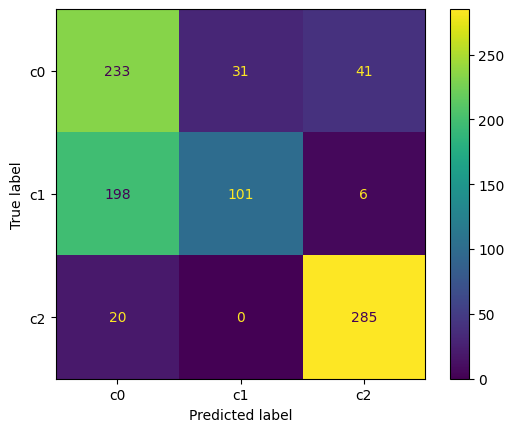

In [ ]:
#training summary

# Metrics on the validation split
val_generator.reset()
val_preds = model.predict(val_generator)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_generator.classes
print(classification_report(y_true, y_pred, target_names=list(train_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=list(train_generator.class_indices.keys())).plot()
plt.show()

# Save: to avoid custom loss deserialization errors later, load with compile=False
model.save("distracted_driver_detection.keras")


In [ ]:
tr_loss = history.history['loss']
tr_accuracy = history.history['accuracy']

val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']

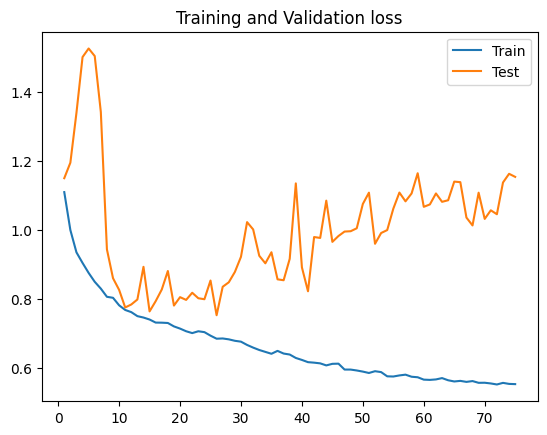

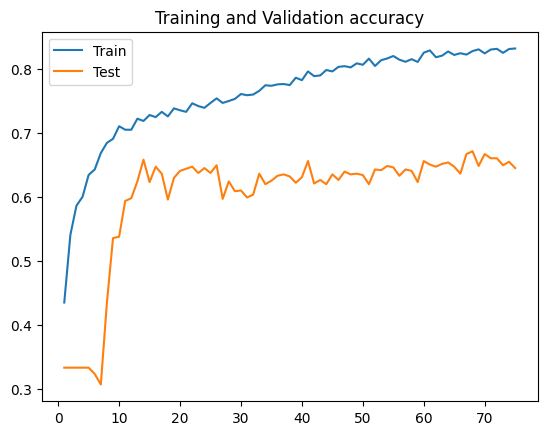

In [ ]:
#graph training results
epchs = list(range(1,len(tr_loss)+1))
plt.plot(epchs,tr_loss,label='Train')
plt.plot(epchs,val_loss,label='Test')
plt.title("Training and Validation loss")
plt.legend()
plt.show()


plt.plot(epchs,tr_accuracy,label='Train')
plt.plot(epchs,val_accuracy,label='Test')
plt.title("Training and Validation accuracy")
plt.legend()
plt.show()

/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'cbam', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'cbam_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Found 38 test images.
✅ Saved predictions grid with captions to predictions_grid.png


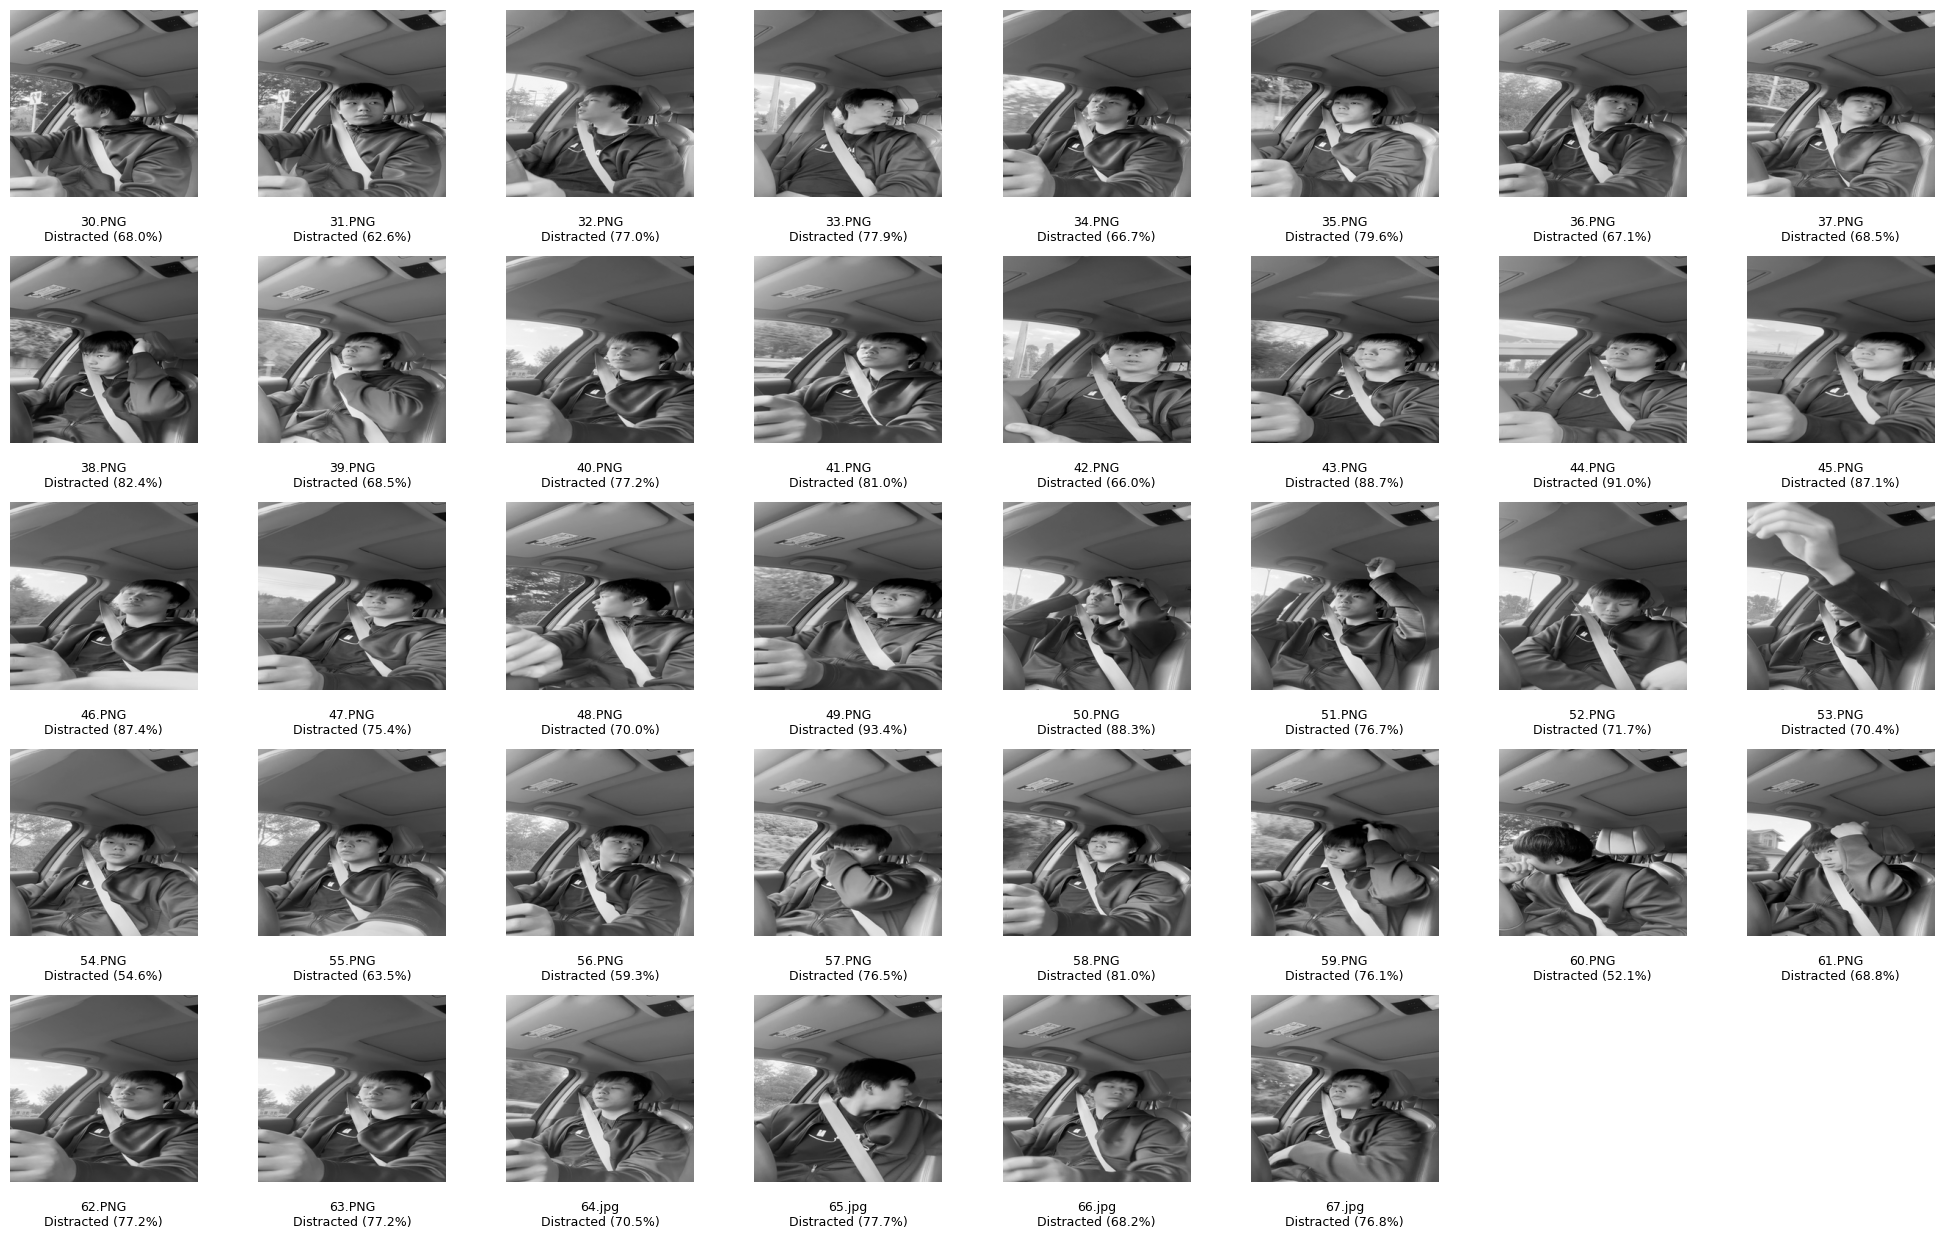

In [ ]:
import os, math
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
import keras

keras.config.enable_unsafe_deserialization()

@keras.saving.register_keras_serializable(package="ddd")
class ChannelAttention(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        c = int(input_shape[-1])
        hidden = max(c // self.ratio, 8)
        self.fc1 = layers.Dense(hidden, activation='relu', kernel_initializer='he_normal')
        self.fc2 = layers.Dense(c, activation='sigmoid', kernel_initializer='he_normal')
        self.fc1m = layers.Dense(hidden, activation='relu', kernel_initializer='he_normal')
        self.fc2m = layers.Dense(c, activation='sigmoid', kernel_initializer='he_normal')

    def call(self, x):
        avg = tf.reduce_sum(x, axis=[1, 2]) / tf.cast(tf.shape(x)[1] * tf.shape(x)[2], x.dtype)
        mx = tf.reduce_max(x, axis=[1, 2])
        ca = self.fc2(self.fc1(avg))
        cm = self.fc2m(self.fc1m(mx))
        w = tf.nn.sigmoid(ca + cm)
        w = tf.reshape(w, (-1, 1, 1, tf.shape(w)[-1]))
        return x * w


@keras.saving.register_keras_serializable(package="ddd")
class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')

    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx = tf.reduce_max(x, axis=-1, keepdims=True)
        s = tf.concat([avg, mx], axis=-1)
        s = self.conv(s)
        return x * s


@keras.saving.register_keras_serializable(package="ddd")
class CBAM(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ca = ChannelAttention(ratio=ratio)
        self.sa = SpatialAttention()

    def call(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

model = load_model(
    "distracted_driver_detection.keras",
    compile=False,
    custom_objects={
        "CBAM": CBAM,
        "ChannelAttention": ChannelAttention,
        "SpatialAttention": SpatialAttention
    }
)

class_names = ["Safe driving", "Distracted", "Tired"]

folder = "/home/lurpd/DevelopmentWSL2/Datasets/MyData/"
image_paths = []

# find valid image files (30–63)
for i in range(30, 68):
    for ext in [".png", ".jpg", ".jpeg", ".PNG", ".JPG", ".JPEG"]:
        path = os.path.join(folder, f"{i}{ext}")
        if os.path.exists(path):
            image_paths.append(path)
            break

print(f"Found {len(image_paths)} test images.")

cols = 8
rows = math.ceil(len(image_paths) / cols)
plt.figure(figsize=(cols * 2.5, rows * 2.5))

for idx, img_path in enumerate(image_paths):
    img = Image.open(img_path).convert("L")
    img = img.resize((256, 256), Image.Resampling.LANCZOS)
    img_array = np.expand_dims(np.array(img).astype(np.float32) / 255.0, axis=(0, -1))

    preds = model.predict(img_array, verbose=0)[0]
    p_safe, p_dist, p_tired = preds

    risk = p_dist + p_tired
    if risk > 0.5:  # tune 0.5 → 0.4 or 0.6 as needed
        if p_dist >= p_tired:
            label = "Distracted"
        else:
            label = "Tired"
    else:
        label = "Safe driving"
    conf = np.max(preds) * 100

    ax = plt.subplot(rows, cols, idx + 1)
    ax.imshow(np.squeeze(img), cmap='gray')
    ax.axis("off")

    caption = f"{os.path.basename(img_path)}\n{label} ({conf:.1f}%)"
    plt.text(
        0.5, -0.1, caption,
        ha='center', va='top',
        fontsize=9, wrap=True,
        transform=ax.transAxes
    )

plt.tight_layout()
plt.subplots_adjust(bottom=0.05)  
plt.savefig("predictions_grid.png", dpi=150, bbox_inches="tight")
print("✅ Saved predictions grid with captions to predictions_grid.png")


try:
    if os.path.exists("/mnt/c/Windows"):
        os.system("explorer.exe predictions_grid.png".replace("/", "\\"))
except Exception:
    pass
